# MOUNT THE GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

# IMPORT THE PYTHON LIBRARIES

In [2]:
import tqdm as tqdm
from tensorflow import keras
from tensorflow.keras import layers
import os, glob
import matplotlib.pyplot as plt
import cv2
import random
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
from keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose, BatchNormalization, ReLU
from keras.callbacks import ModelCheckpoint, History
import tensorflow.keras.backend as K

# PREPROCESS AND PREPARE THE DATA IN THE FORM OF TENSOR

IT IS A 2D MODEL: TENSOR SHAPE WILL BE **[BATCH, HEIGHT, WIDTH, CHANNEL]**

In [4]:
TrainPath = r'C:\Users\DELL\Desktop\VESSEL12\TRAIN'

ImagePath = os.path.join(TrainPath, 'IMAGES')
LabelPath = os.path.join(TrainPath, 'LABELS')

print(ImagePath, '\n', LabelPath)

C:\Users\DELL\Desktop\VESSEL12\TRAIN\IMAGES 
 C:\Users\DELL\Desktop\VESSEL12\TRAIN\LABELS


In [5]:
ValPath = r'C:\Users\DELL\Desktop\VESSEL12\VAL'

ValImagePath = os.path.join(ValPath, 'IMAGES')
ValLabelPath = os.path.join(ValPath, 'LABELS')

print(ValImagePath, '\n', ValLabelPath)

C:\Users\DELL\Desktop\VESSEL12\VAL\IMAGES 
 C:\Users\DELL\Desktop\VESSEL12\VAL\LABELS


In [6]:
eps = 1e-7
img_rows = 256
img_columns = 256
def preprocess_images(path): #, temp = 5000
  '''preprocess functions take the images
    read them, resize them convert them to array
    normalize the images, and convert it to a trainable tensor'''
  ImageList=[]
  img_list=glob.glob(path + '/*.png')
  img_list.sort()
  #img_list = img_list[:temp]
  #print()
  print("No of images found:"+str(len(img_list)))
  for ii in tqdm.tqdm(range(len(img_list))):
    img = cv2.imread(img_list[ii])
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_img = cv2.resize(gray_img, (img_rows,img_columns))
    img_array = np.array(gray_img, dtype = np.float32)
    norm_im_array = (img_array - np.min(img_array))/((np.max(img_array) - np.min(img_array)+eps))
    ImageList.append(norm_im_array)
  ImageArray = np.asarray(ImageList, dtype = np.float32)
  ImageArray = ImageArray[..., np.newaxis]
  return ImageArray

# SANITY CHECK ON THE DATASET

In [8]:
X_train = preprocess_images(ImagePath)
Y_train = preprocess_images(LabelPath)

X_val = preprocess_images(ValImagePath)
Y_val = preprocess_images(ValLabelPath)

No of images found:5743


100%|█████████████████████████████████████████████████████████████████████████████| 5743/5743 [00:41<00:00, 138.56it/s]


No of images found:5743


100%|█████████████████████████████████████████████████████████████████████████████| 5743/5743 [00:28<00:00, 201.62it/s]


No of images found:1400


100%|█████████████████████████████████████████████████████████████████████████████| 1400/1400 [00:10<00:00, 133.87it/s]


No of images found:1400


100%|█████████████████████████████████████████████████████████████████████████████| 1400/1400 [00:06<00:00, 218.71it/s]


In [9]:
print(X_train.shape, '\t', type(X_train)) # NOTICE THE TENSOR SHAPE
print(X_val.shape, '\t', type(X_val))
print(Y_train.shape, '\t', type(Y_train))
print(Y_val.shape, '\t', type(Y_val))

(5743, 256, 256, 1) 	 <class 'numpy.ndarray'>
(1400, 256, 256, 1) 	 <class 'numpy.ndarray'>
(5743, 256, 256, 1) 	 <class 'numpy.ndarray'>
(1400, 256, 256, 1) 	 <class 'numpy.ndarray'>


5138


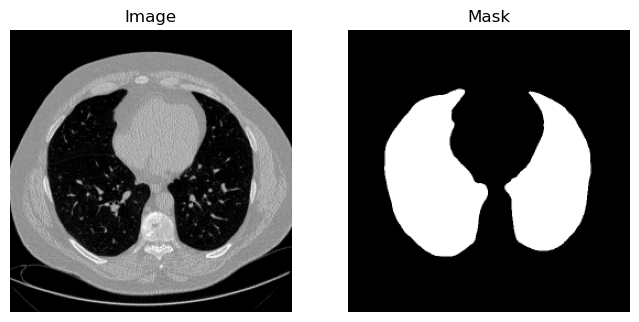

In [14]:
# SANITY CHECK
X = random.randint(1, len(X_train)-1)
print(X)
plt.figure(figsize=(8, 8))
plt.subplot(121)
plt.imshow(np.squeeze(X_train[X,:,:]), cmap='gray')
plt.title('Image')
plt.axis('off')
plt.subplot(122)
plt.imshow(np.squeeze(Y_train[X,:,:]), cmap='gray')
plt.title('Mask')
plt.axis('off')
plt.show()

# CREATE THE U-NET SEGMENTATION MODEL

In [16]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.models import Model

def unet_model(input_shape=(256, 256, 1)):
    inputs = Input(input_shape)
    
    # Encoder
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2, 2))(c1)  # 128
    
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2, 2))(c2)  # 64
    
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    p3 = MaxPooling2D((2, 2))(c3)  # 32
    
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    p4 = MaxPooling2D((2, 2))(c4)  # 16
    
    c5 = Conv2D(128, (3, 3), activation='relu', padding='same')(p4)
    p5 = MaxPooling2D((2, 2))(c5)  # 8
    
    # Bottleneck
    c6 = Conv2D(256, (3, 3), activation='relu', padding='same')(p5)
    
    # Decoder
    u7 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c5])
    c7 = Conv2D(128, (3, 3), activation='relu', padding='same')(u7)
    
    u8 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c4])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    
    u9 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c3])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    
    u10 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(c9)
    u10 = concatenate([u10, c2])
    c10 = Conv2D(64, (3, 3), activation='relu', padding='same')(u10)
    
    u11 = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(c10)
    u11 = concatenate([u11, c1])
    c11 = Conv2D(32, (3, 3), activation='relu', padding='same')(u11)
    
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c11)
    
    model = Model(inputs, outputs)
    return model


# Create model
model = unet_model()
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 1)]        0         []                            
                                                                                                  
 conv2d_8 (Conv2D)           (None, 256, 256, 32)         320       ['input_2[0][0]']             
                                                                                                  
 max_pooling2d_3 (MaxPoolin  (None, 128, 128, 32)         0         ['conv2d_8[0][0]']            
 g2D)                                                                                             
                                                                                                  
 conv2d_9 (Conv2D)           (None, 128, 128, 64)         18496     ['max_pooling2d_3[0][0]'

# **CNN MODEL COMPILATION**

**1.LOSS FUNCTION**

**2. OPTIMIZER**

**3. METRICS TO BE MONITORED DURING TRAINING**

**4. MODEL COMPILE**

**5. MODEL CHECKPOINTING**


In [17]:
# DICE COEFFICIENT and DICE LOSS
smooth = 1
eps = 1e-7
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * (intersection)+smooth ) / (K.sum(y_true_f) + K.sum(y_pred_f)+smooth)

def dice_coef_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)

In [18]:
# define optomizer
optimizer = keras.optimizers.Adam(0.0001)

# Define loss
dice_loss = dice_coef_loss

# define metrics
metrics = [dice_coef]

#Compile the model

model.compile(optimizer, loss = dice_loss, metrics = metrics)

In [19]:
# CHECKPOINTING and SAVING
PATH = '/lung_seg_model.keras'
model_checkpoint = [keras.callbacks.ModelCheckpoint(PATH, save_weights_only=False, save_best_only=True, monitor='val_loss', mode='min')]

# TRAIN THE U-NET MODEL USING **model.fit()**

In [20]:
history = model.fit(
                      X_train,
                      Y_train,
                      batch_size=16,
                      epochs=50,
                      validation_data=(X_val, Y_val),
                      callbacks=[model_checkpoint],
                    )

Epoch 1/50
 11/359 [..............................] - ETA: 10:11 - loss: 0.7710 - dice_coef: 0.2290

KeyboardInterrupt: 

# PLOT THE MODEL LOSS AND DICE PROGRESSION OVER THE EPOCHS

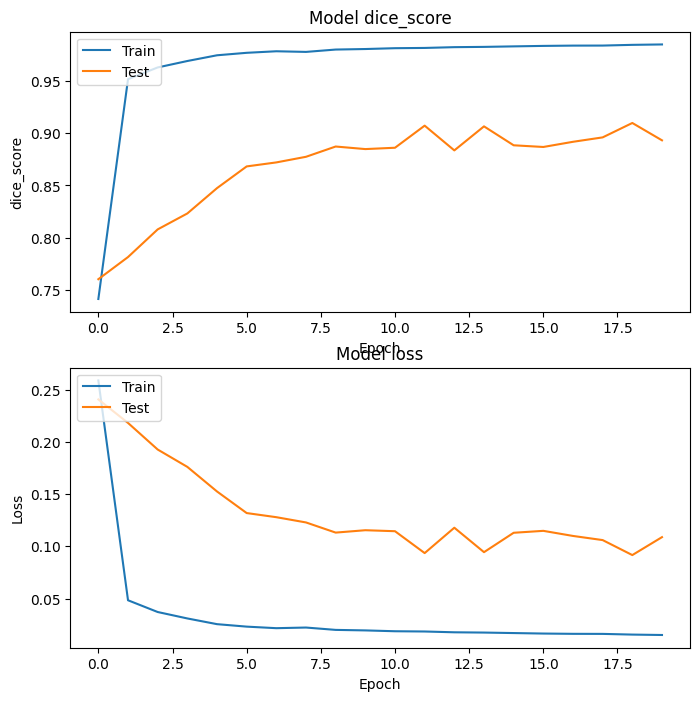

In [ ]:
# Plot training & validation iou_score values
plt.figure(figsize=(8,8))
plt.subplot(211)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Model dice_score')
plt.ylabel('dice_score')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(212)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# TEST THE MODEL'S PERFORMANCE ON THE TEST DATASET

In [ ]:
model = tf.keras.models.load_model('/lung_seg_model.keras',
                                    custom_objects={'dice_coef_loss': dice_coef_loss, 'dice_coef': dice_coef})

In [ ]:
def model_predict():
  print('Prediction Initialized')
  predicted_mask = model.predict(X_val, verbose=1)
  print('Predicted mask shape:', predicted_mask.shape)
  print('Prediction Done Successfully')

  np.save('/predictions.npy', predicted_mask)
  print('Predicted masks saved successfully')

In [ ]:
model_predict()

Prediction Initialized
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 387ms/step
Predicted mask shape: (500, 256, 256, 1)
Prediction Done Successfully
Predicted masks saved successfully


In [ ]:
# LOAD THE PREDICTED IMAGES
predicted_mask = np.load('/predictions.npy.npy')

Displaying Image No: 129


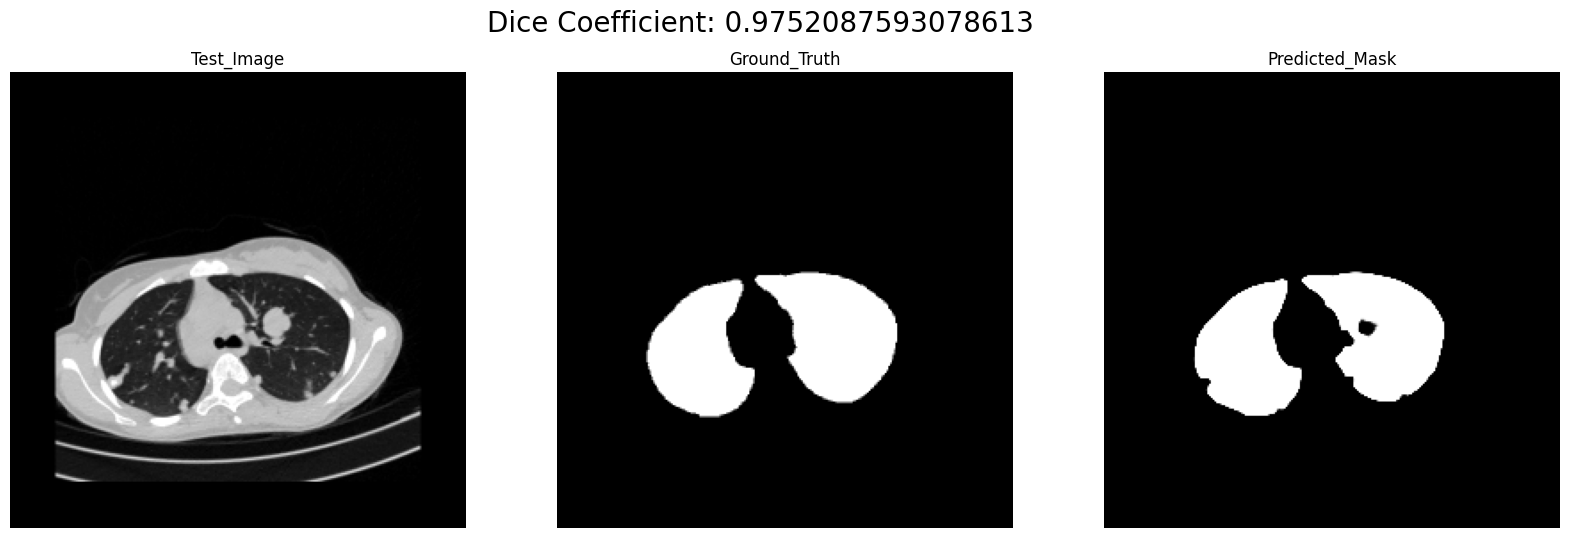

In [ ]:
# VISUALIZE THE RESULTS
X = random.randint(0, 499)
print(f'Displaying Image No: {X}')
plt.figure(figsize=(20, 6))
plt.subplot(131)
plt.imshow(np.squeeze(X_val[X,:,:]), cmap='gray')
plt.title('Test_Image')
plt.axis('off')
plt.subplot(132)
plt.imshow(np.squeeze(Y_val[X,:,:]), cmap='gray')
plt.title('Ground_Truth')
plt.axis('off')
plt.subplot(133)
plt.imshow(np.squeeze(predicted_mask[X,:,:]), cmap='gray')
plt.title('Predicted_Mask')
plt.suptitle(f'Dice Coefficient: {dice_coef(Y_val[X,:,:], predicted_mask[X,:,:])}', fontsize=20)
plt.axis('off')
plt.show()

In [ ]:
XX = np.squeeze(X_val[X,:,:]) * np.squeeze(predicted_mask[X,:,:])

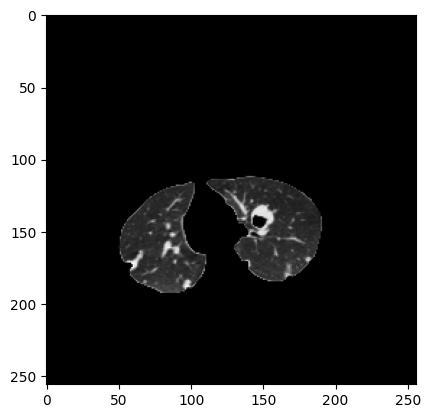

In [ ]:
plt.imshow(XX, cmap='gray')